In [2]:
import numpy as np
import matplotlib.pyplot as plt
#import scistyles
import flups
import colorcet
from glob import glob
from pyspan.utils import between
from collections import namedtuple
from scipy.signal import savgol_filter
import lmfit
from itertools import chain
from scipy.interpolate import UnivariateSpline
import os.path as pth

In [ ]:
%matplotlib widget
#plt.style.use("report-sp")

# Check PCF: do we cover the required bandwidth?


In [5]:
# load photometric measurements
pcfs = glob("**/pcf_*.txt", recursive=True)
print(pcfs)
pcfs = {pth.basename(fn): np.loadtxt(fn).T for fn in pcfs}

pix = np.arange(len(list(pcfs.values())[0][0]))
wl = pix*0.123+244.284
wl_exp = wl.copy()

[]


IndexError: list index out of range

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Counts')

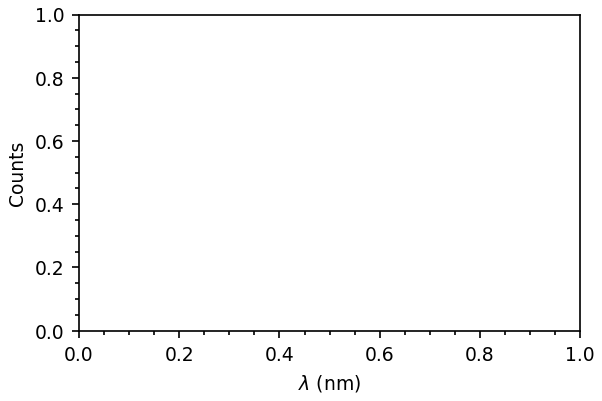

In [6]:
plt.figure()
for fn, (pix, s) in pcfs.items():
    plt.plot(wl, s, label=fn)
plt.legend()
plt.xlabel("$\lambda$ (nm)")
plt.ylabel("Counts")

In [ ]:
flups_data = flups.io.load_txt("240624_run0104.txt")
assert np.allclose(flups_data[1], wl)
pcfs = {fn: v[1] for fn, v in pcfs.items()}
t, wl, sig = flups_data
proj = np.percentile(sig, 99, axis=0)

In [ ]:
sig.shape, t.size, wl.size

((351, 1600), 351, 1600)

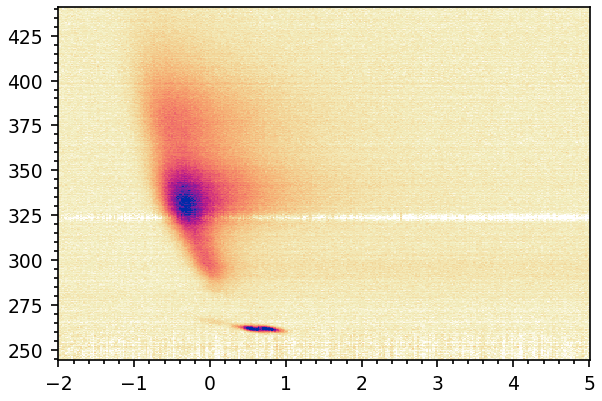

In [ ]:
plt.figure()
vmin=-5
vmax = 50
plt.pcolormesh(t, wl, sig.T, vmin=vmin, vmax=vmax, cmap="cet_CET_L17")

In [ ]:
# Change everything to `PBBOhe`, `PBBOac` etc. There is no reason to separate solvant and molecule in this case.
masks = {}  # todo: use (dye, solvant).. no. 

masks["pcf_PBBO_ac.txt"] = between(wl, 270, 360)
masks["pcf_C153_ac.txt"] = between(wl, 330, np.infty)
masks["pcf_C6H_ac.txt"] = between(wl, 300, 420)


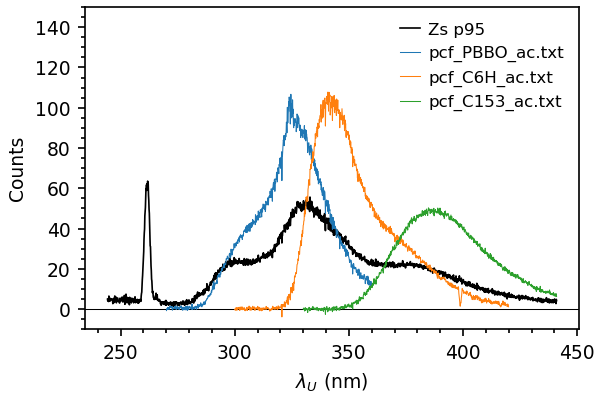

In [ ]:
plt.figure()
pcf_plot_kw = dict(lw=0.5)
plt.axhline(0, color="k", lw=0.5)
plt.plot(wl, proj, color="k", label="Zs p95")
for fn in ["pcf_PBBO_ac.txt",
           "pcf_C6H_ac.txt",
           "pcf_C153_ac.txt"
          ]:
    m = masks.get(fn, np.full_like(wl, True))
    plt.plot(wl.compress(m), pcfs[fn].compress(m), label=fn, **pcf_plot_kw)
plt.ylim(-10, 150)
plt.legend()
plt.xlabel("$\lambda_U$ (nm)")
plt.ylabel("Counts")
plt.savefig("check_pcf.png", dpi=600)

The reference dyes cover the useful wavelength range.

# compute pcf

Ouch this needs cleanup

# load reference spectra
We measured C6H and PBBO. Use C153 from litt.

$$
c = S_\mathrm{ref}(\lambda_\mathrm{U})/S_\mathrm{FLUPS}(\lambda_\mathrm{U})
$$

where $S_\mathrm{FLUPS}(\lambda_\mathrm{U})$ is the measured FLUPS signal on the reference dye, and  $S_\mathrm{ref}(\lambda_\mathrm{U})$ is the reference spectrum.

The reference spectrum is measured at the fluorescence wavelength $\lambda_\mathrm{F}$, and therefore must be jacobian-corrected by $\lambda_\mathrm{F}^2/\lambda_\mathrm{U}^2$.

In [28]:
ref_npz = np.load("240618_fluo_ref.npz")
ref_npz_2 = np.load("240719_fluo_ref.npz")
print(list(ref_npz.keys())+list(ref_npz_2.keys()))

['240618_C6Hac', '240618_PBBOac', '240618_PBBOhe', '240719_C153ac']


In [29]:
ref_record = namedtuple("ref_record", ("wl_f", "wl_u", "s_f", "s_u"))

wl_f = 1/(1/wl_exp -1/1340)
references = {}
for k, d in chain(ref_npz.items(), ref_npz_2.items()):
    dye = k[7:-2]
    solvant = k[-2:]
    wl_org = d[:,0]
    s = d[:,1]

    # resample
    s = np.interp(wl_f, wl_org, s)
    
    
    s /= np.max(s)
    jac = wl_f**2/wl_exp**2
    s_u = s*jac
    s_u /= np.max(s_u)
    references[dye, solvant] = ref_record(wl_f, wl_exp, s, s_u)

In [30]:
# We tried  C153 ac from Niko, however, it doesn't line_up

# s_c153 = flups.analysis.ref_spec_wl(wl_f, "C153")
# s_c153 /= np.max(s_c153)
# jac = wl_f**2/wl_exp**2
# s_u = s_c153 * jac
# s_u /= np.max(s_u)
# references["C153", "ac"] = ref_record(wl_f, wl_exp, s_c153, s_u)

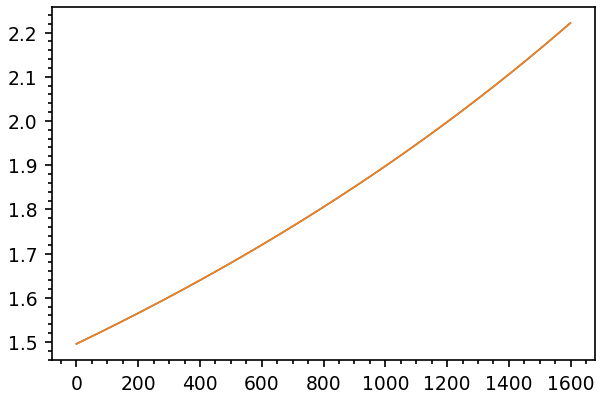

In [31]:
plt.figure()
plt.plot(jac)
plt.plot(np.gradient(wl_f)/np.gradient(wl_exp))

In [32]:
meas = {}
meas_record = namedtuple("meas_record", ("wl_u", "s_u", "is_valid"))
for fn, data in pcfs.items():
    _, dye, solvant = fn[:-4].split("_")
    m = masks.get(fn, np.full_like(wl, True))
    filt = savgol_filter(data, 11, 2)
    meas[dye, solvant] = meas_record(wl_exp, data/np.max(filt), m)

In [34]:
pcf_curves = {}
for k, r in meas.items():
    ref_wl = references[k].wl_u
    ref_s = references[k].s_u
    c = np.interp(meas[k].wl_u, ref_wl, ref_s)/meas[k].s_u
    c = np.where(meas[k].is_valid, c, np.nan)
    pcf_curves[k] = (meas[k].wl_u, c)

In [43]:
# pcf validity masks. Would probably work better with validity intervals,
# which we can manipulate with reference spectra validity intervals.
assert np.allclose(wl_exp, [r.wl_u for r in references.values()])
pcf_is_valid = {}
pcf_is_valid["C6H", "ac"] = between(wl_exp, 326.5, 396)
pcf_is_valid["PBBO", "ac"] = between(wl_exp, 285, 360)
pcf_is_valid["PBBO", "he"] = between(wl_exp, 282, 350)
pcf_is_valid["C153", "ac"] = between(wl_exp, 360, np.infty)

pcf_is_valid = {k: m & ~between(wl_exp, 322, 326.5) for k, m in pcf_is_valid.items()}

In [44]:
pcf_keys = list(pcf_curves.keys())
pcf_mat = np.vstack([p[1] for p in pcf_curves.values()])

pcf_masks = np.vstack([pcf_is_valid[k] for k in pcf_keys])
assert pcf_mat.shape == pcf_masks.shape
mjoint = pcf_masks[:,np.newaxis,:] & pcf_masks[np.newaxis,:,:]

def rmsd(params):
    v = params.valuesdict()
    scales = np.array([v["s_{}{}".format(*k)] for k in pcf_keys])
    y = scales[:,np.newaxis]*pcf_mat
    # compute rmsd, perform all pairwise differences. Diagonal is still there, but will be 0 by definition
    diff = y[:,np.newaxis,:] - y[np.newaxis,:,:]
    
    diff = diff.compress(mjoint.flat)
    return np.sqrt(np.nanmean(diff**2))

In [45]:
pcf_keys

[('C153', 'ac'), ('C6H', 'ac'), ('PBBO', 'ac')]

In [46]:
params = lmfit.Parameters()
for k in pcf_keys:
    params.add(f"s_{k[0]}{k[1]}", value=1, min=0)
params["s_C6Hac"].set(vary=False)
params

name,value,initial value,min,max,vary
s_C153ac,1.00000000,1,0.00000000,inf,True
s_C6Hac,1.00000000,1,0.00000000,inf,False
s_PBBOac,1.00000000,1,0.00000000,inf,True


In [47]:
res = lmfit.minimize(rmsd, params, method="nelder")
scales_rmsd = {k: res.params.valuesdict()["s_{}{}".format(*k)] for k in pcf_keys}
scales_rmsd

{('C153', 'ac'): 0.5544507081675729,
 ('C6H', 'ac'): 1,
 ('PBBO', 'ac'): 1.5768040172998012}

In [48]:
res

(244.284, 440.961)

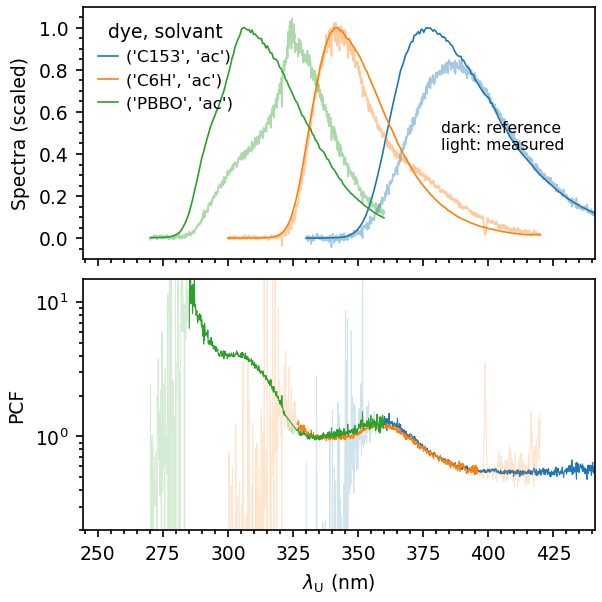

In [49]:
# scaling by average
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(4,4))
scales = {}
for k, (wl_u, c) in pcf_curves.items():
    dye, solvant = k
    if dye == "C153":
        continue
    m = between(wl_u, 330, 340)
    scale = c.compress(m).mean()
    scales[k] = 1/scale

for k, (wl_u, c) in pcf_curves.items():
    dye, solvant = k
    if dye != "C153":
        continue
    lo, hi = 360, 375
    m = between(wl_u, lo, hi)
    wl_ref, c_ref = pcf_curves["C6H", solvant]
    m_ref = between(wl_ref, lo, hi)
    scale = c.compress(m).mean()/c_ref.compress(m_ref).mean()*scales["C6H", solvant]
    scales[k] = 1/scale

        
for k, m in meas.items():
    
    r = references[k]
    c = axes[0].plot(r.wl_u.compress(m.is_valid), r.s_u.compress(m.is_valid), label=k)
    axes[0].plot(m.wl_u.compress(m.is_valid), m.s_u.compress(m.is_valid), c=c[0].get_color(), alpha=0.4)
    axes[0].legend(title="dye, solvant")
    wl_p, p = pcf_curves[k]
    axes[1].plot(wl_p, p*scales[k], lw=0.5, color=c[0].get_color(), alpha=0.2)
    m = pcf_is_valid[k]
    axes[1].plot(wl_p.compress(m), p.compress(m)*scales[k], lw=0.5, color=c[0].get_color())
axes[1].set_yscale("log")
axes[1].set_ylim(0.2, 15)
axes[0].text(0.7, 0.55, "dark: reference\nlight: measured", ha="left", va="top", transform=axes[0].transAxes, fontsize="small")
axes[0].set_ylabel("Spectra (scaled)")
axes[1].set_ylabel("PCF")
axes[1].set_xlabel(r"$\lambda_\mathrm{U}$ (nm)")
axes[1].set_xlim(wl_exp[0], wl_exp[-1])
#plt.savefig("240619_pcfs.png", dpi=300)

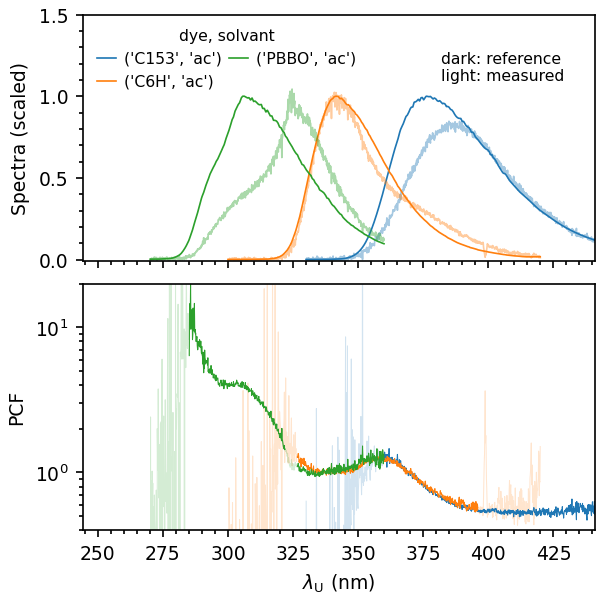

In [51]:
# scaling by average
fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(4,4))

        
for k, m in meas.items():
    
    r = references[k]
    c = axes[0].plot(r.wl_u.compress(m.is_valid), r.s_u.compress(m.is_valid), label=k)
    axes[0].plot(m.wl_u.compress(m.is_valid), m.s_u.compress(m.is_valid), c=c[0].get_color(), alpha=0.4)
    
    wl_p, p = pcf_curves[k]
    axes[1].plot(wl_p, p*scales_rmsd[k], lw=0.5, color=c[0].get_color(), alpha=0.2, zorder=-1)
    m = pcf_is_valid[k]
    axes[1].plot(wl_p, np.where(m, p*scales_rmsd[k], np.nan), lw=0.5, color=c[0].get_color())
axes[0].legend(title="dye, solvant", fontsize='small', ncols=2, title_fontsize="small", loc="upper left")
axes[1].set_yscale("log")
axes[1].set_ylim(0.4, 20)
axes[0].text(0.7, 0.85, "dark: reference\nlight: measured", ha="left", va="top", transform=axes[0].transAxes, fontsize="small")
axes[0].set_ylabel("Spectra (scaled)")
axes[1].set_ylabel("PCF")
axes[1].set_xlabel(r"$\lambda_\mathrm{U}$ (nm)")
axes[1].set_xlim(wl_exp[0], wl_exp[-1])
axes[0].set_ylim(-0.01, 1.5)
plt.savefig("240719_pcfs_scaled.png", dpi=300)

In [52]:
pcf_selected = {k: (wl_, np.where(pcf_is_valid[k], p_*scales_rmsd[k], np.nan)) for k, (wl_, p_) in pcf_curves.items()}


C:\Users\palatosa\AppData\Local\Temp\ipykernel_18712\4039488657.py:6: RankWarning: Polyfit may be poorly conditioned
  polf = np.poly1d(np.polyfit(pol_x, pol_y, deg=20))


Text(0, 0.5, 'c')

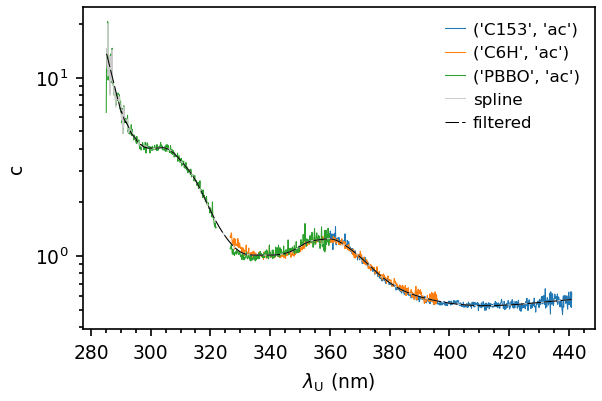

In [86]:
plt.figure()

#prepare dataset for polynomial fitting.
pol_x = np.hstack([wl.compress(np.isfinite(p)) for wl, p in pcf_selected.values()])
pol_y = np.hstack([p.compress(np.isfinite(p)) for wl, p in pcf_selected.values()])
polf = np.poly1d(np.polyfit(pol_x, pol_y, deg=20))
lo = np.min(pol_x)
hi = np.infty
wl_pol = wl_exp.compress(between(wl_exp, lo, hi))

srti = np.argsort(pol_x)
spln = UnivariateSpline(pol_x[srti], pol_y[srti], s=0.005*len(pol_x))
try:
    filtered = savgol_filter(spln(wl_pol), 75, 2)
except np.linalg.LinAlgError:
    filtered = None
pcf = np.full_like(wl_exp, np.nan)
pcf[wl_exp > lo] = filtered
for k, (wl, p) in pcf_selected.items():
    plt.plot(wl, p, label=k, lw=0.5)
#plt.plot(wl_pol, polf(wl_pol), lw=0.5)
plt.plot(wl_pol, spln(wl_pol), color="0.8", lw=0.5, label="spline")
if filtered is not None:
    plt.plot(wl_pol, filtered, color="k", ls=(0, (13, 3)), lw=0.5, label="filtered")
plt.yscale("log")
plt.legend()
plt.xlabel(r"$\lambda_\mathrm{U}$ (nm)")
plt.ylabel("c")

In [87]:
np.savez("240624_pcf_final.npz", wl=wl_exp, pcf=pcf)